# Quantum Repeater Network — Metrics Study
Five figures studying distillation, multiplexing, density, and distillation level.

> All runs use `multiphoton=False`.  
> Increase `N_NODES` and `N_TRIALS` for smoother curves (at the cost of runtime).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from itertools import product

from sequential_repeaters_dist import (
    RepeaterParams, QuantumRepeaterNetwork, build_s2_graph
)

## Global settings

In [2]:
# ── Physical parameters ───────────────────────────────────────────────────────
def make_params():
    p = RepeaterParams()
    p.p_det     = 0.95
    p.alpha     = 0.18
    p.q_0       = 0.01
    p.nu        = 1e9
    p.R_dark    = 100
    p.delta_det = 100e-12
    p.p_pair    = 0.05
    p.eta_c     = 0.8
    p.P_BSM     = 0.5
    p.T_coh     = 0.05
    return p

# ── Sweep settings ────────────────────────────────────────────────────────────
N_NODES   = 30        # nodes per graph realisation  (raise for smoother curves)
N_TRIALS  = 3         # random graph realisations averaged per data point
BETA      = 2.6261
MU        = 0.0233
M_BURST   = 1e4       # multiplexing mode for single_burst / accumulated

# Density sweep: rho [nodes/km²]  →  scale_km = sqrt(N / (pi * rho))
RHOS      = np.array([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5])
DIST_LEVELS = [1, 2, 3]   # distillation levels for sweeps

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', font_scale=1.05)
METRIC_LABELS = {
    'avg_rate':               'Avg rate  [pairs/s]',
    'avg_dist_weighted_rate': 'Avg dist-weighted rate  [pairs·km/s]',
    'reachability':           'Reachability  [%]',
}
METRICS = list(METRIC_LABELS.keys())

def scale_metric(key, val):
    """Convert reachability to percent, leave others untouched."""
    return val * 100 if key == 'reachability' else val

print('Settings loaded.')

Settings loaded.


## Helper: run one experiment

In [3]:
def density_to_scale(N, rho):
    """Convert node density [nodes/km²] to km scale factor for build_s2_graph."""
    return np.sqrt(N / (np.pi * rho))


def run_metrics(
    scale_km,
    distillation=True,
    multiplexing_type=None,
    distillation_level=1,
    distillation_time='before_swap',
    n_trials=N_TRIALS,
):
    """
    Build N_TRIALS random graphs at the given scale, compute network_metrics
    for each, and return the average of the three scalar metrics.
    """
    results = {m: [] for m in METRICS}

    for _ in range(n_trials):
        A, dist, coords = build_s2_graph(
            N=N_NODES, beta=BETA, mu=MU, scale=float(scale_km)
        )
        net = QuantumRepeaterNetwork(
            make_params(), A, dist, coords,
            architecture='node',
            scale=float(scale_km),
            multiphoton=False,
            distillation=distillation,
            multiplexing_type=multiplexing_type,
            M=M_BURST,
            distillation_level=distillation_level,
            distillation_time=distillation_time,
        )
        m = net.network_metrics(verbose=False)
        for key in METRICS:
            results[key].append(scale_metric(key, m[key]))

    return {k: np.mean(v) for k, v in results.items()}


def make_fig(n_cols=3, title='', height=4.5):
    fig, axes = plt.subplots(1, n_cols, figsize=(5.5 * n_cols, height))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    return fig, axes


def finish_axes(axes, xlabel, log_y=True):
    for ax, key in zip(axes, METRICS):
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(METRIC_LABELS[key], fontsize=11)
        if log_y and key != 'reachability':
            ax.set_yscale('log')
        ax.legend(fontsize=9, framealpha=0.7)

print('Helpers ready.')

Helpers ready.


---
## Figure 1 — Master graph
Distillation ON. All three multiplexing modes × before/after swap → 6 lines.  
X-axis: distillation level. Fixed density (mid-range).

  mux=None | time=before_swap | level=1 …
  mux=None | time=before_swap | level=2 …
  mux=None | time=before_swap | level=3 …
  mux=None | time=after_swap | level=1 …
  mux=None | time=after_swap | level=2 …
  mux=None | time=after_swap | level=3 …
  mux=single_burst | time=before_swap | level=1 …
  mux=single_burst | time=before_swap | level=2 …
  mux=single_burst | time=before_swap | level=3 …
  mux=single_burst | time=after_swap | level=1 …
  mux=single_burst | time=after_swap | level=2 …
  mux=single_burst | time=after_swap | level=3 …
  mux=accumulated | time=before_swap | level=1 …
  mux=accumulated | time=before_swap | level=2 …
  mux=accumulated | time=before_swap | level=3 …
  mux=accumulated | time=after_swap | level=1 …
  mux=accumulated | time=after_swap | level=2 …
  mux=accumulated | time=after_swap | level=3 …


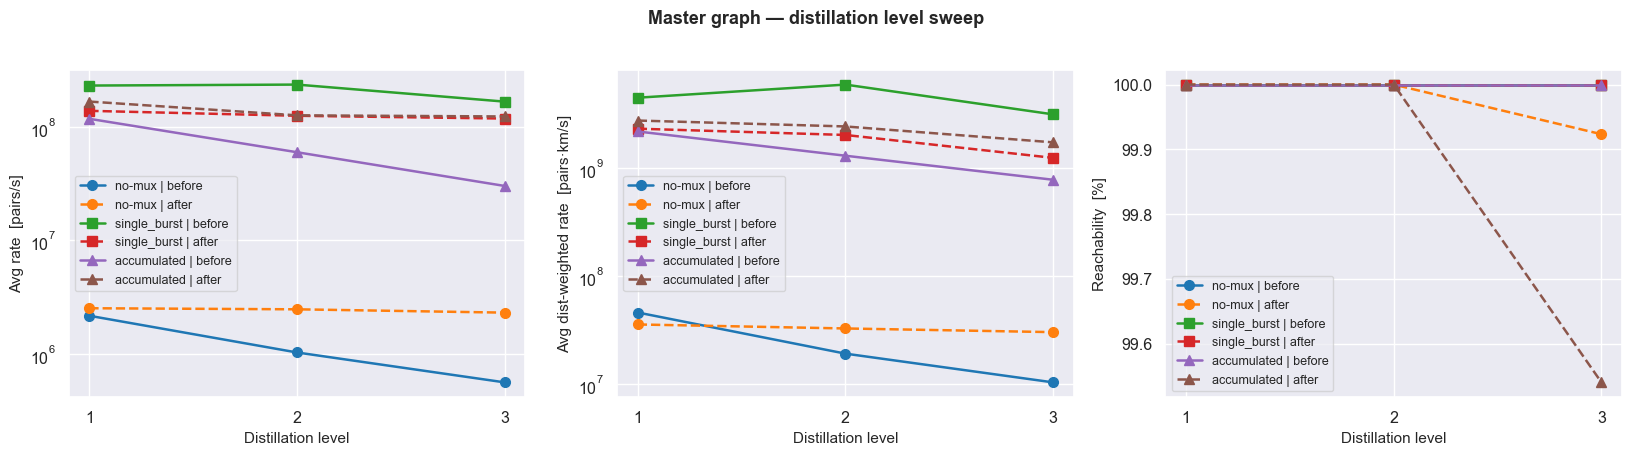

Figure 1 saved.


In [4]:
MUX_MODES  = [None, 'single_burst', 'accumulated']
DIST_TIMES = ['before_swap', 'after_swap']
LEVELS     = [1, 2, 3]

# Fixed mid-density for the master sweep
RHO_MASTER = 0.05
SCALE_MASTER = density_to_scale(N_NODES, RHO_MASTER)

# Palette: 6 colours (3 mux × 2 times)
palette = sns.color_palette('tab10', 6)
linestyles = ['-', '--']   # before / after
mux_markers = ['o', 's', '^']

fig1, axes1 = make_fig(title='Master graph — distillation level sweep')

colour_idx = 0
for mi, mux in enumerate(MUX_MODES):
    for ti, dtime in enumerate(DIST_TIMES):
        label = f"{mux or 'no-mux'} | {dtime.replace('_swap','')}"
        color = palette[colour_idx]
        ls    = linestyles[ti]
        mk    = mux_markers[mi]
        colour_idx += 1

        row_data = {m: [] for m in METRICS}
        for lv in LEVELS:
            print(f'  mux={mux} | time={dtime} | level={lv} …')
            res = run_metrics(
                SCALE_MASTER,
                distillation=True,
                multiplexing_type=mux,
                distillation_level=lv,
                distillation_time=dtime,
            )
            for m in METRICS:
                row_data[m].append(res[m])

        for ax, m in zip(axes1, METRICS):
            ax.plot(LEVELS, row_data[m], marker=mk, linestyle=ls,
                    color=color, label=label, linewidth=1.8, markersize=7)

finish_axes(axes1, xlabel='Distillation level')
for ax in axes1:
    ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('plots/fig1_master.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## Figure 2 — Distillation level study
Distillation ON, no multiplexing, distillation_time=before.  
Lines = different densities. X-axis = distillation level.

  rho=0.005 | level=1 …
  rho=0.005 | level=2 …
  rho=0.005 | level=3 …
  rho=0.02 | level=1 …
  rho=0.02 | level=2 …
  rho=0.02 | level=3 …
  rho=0.1 | level=1 …
  rho=0.1 | level=2 …
  rho=0.1 | level=3 …
  rho=0.5 | level=1 …
  rho=0.5 | level=2 …
  rho=0.5 | level=3 …


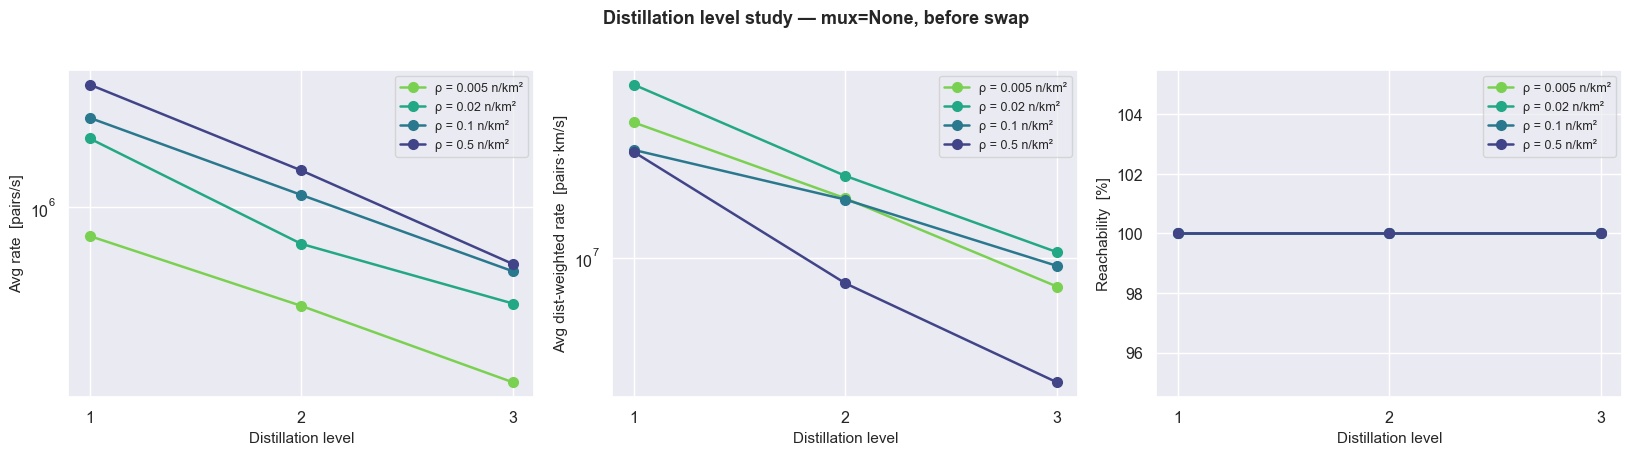

Figure 2 saved.


In [5]:
RHOS_2  = np.array([0.005, 0.02, 0.1, 0.5])
palette2 = sns.color_palette('viridis_r', len(RHOS_2))

fig2, axes2 = make_fig(title='Distillation level study — mux=None, before swap')

for ci, rho in enumerate(RHOS_2):
    scale_km = density_to_scale(N_NODES, rho)
    label    = f'ρ = {rho} n/km²'

    row_data = {m: [] for m in METRICS}
    for lv in LEVELS:
        print(f'  rho={rho} | level={lv} …')
        res = run_metrics(
            scale_km,
            distillation=True,
            multiplexing_type=None,
            distillation_level=lv,
            distillation_time='before_swap',
        )
        for m in METRICS:
            row_data[m].append(res[m])

    for ax, m in zip(axes2, METRICS):
        ax.plot(LEVELS, row_data[m], marker='o', color=palette2[ci],
                label=label, linewidth=1.8, markersize=7)

finish_axes(axes2, xlabel='Distillation level')
for ax in axes2:
    ax.set_xticks(LEVELS)
plt.tight_layout()
plt.savefig('plots/fig2_distillation_level.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## Figure 3 — Before vs After swap
Distillation ON, mux=None, distillation_level=1.  
Lines = before / after. X-axis = density.

  time=before_swap | rho=0.005 …
  time=before_swap | rho=0.01 …
  time=before_swap | rho=0.02 …
  time=before_swap | rho=0.05 …
  time=before_swap | rho=0.1 …
  time=before_swap | rho=0.2 …
  time=before_swap | rho=0.5 …
  time=after_swap | rho=0.005 …
  time=after_swap | rho=0.01 …
  time=after_swap | rho=0.02 …
  time=after_swap | rho=0.05 …
  time=after_swap | rho=0.1 …
  time=after_swap | rho=0.2 …
  time=after_swap | rho=0.5 …


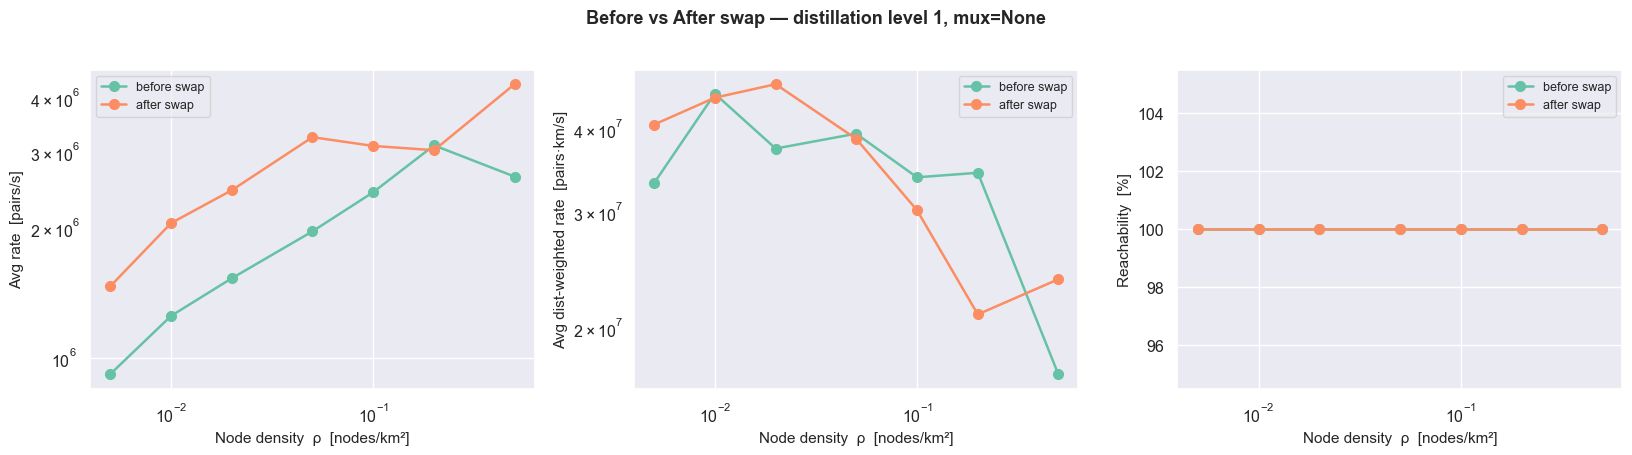

Figure 3 saved.


In [6]:
palette3 = sns.color_palette('Set2', 2)
fig3, axes3 = make_fig(title='Before vs After swap — distillation level 1, mux=None')

for ti, dtime in enumerate(DIST_TIMES):
    label = dtime.replace('_', ' ')
    row_data = {m: [] for m in METRICS}

    for rho in RHOS:
        scale_km = density_to_scale(N_NODES, rho)
        print(f'  time={dtime} | rho={rho} …')
        res = run_metrics(
            scale_km,
            distillation=True,
            multiplexing_type=None,
            distillation_level=1,
            distillation_time=dtime,
        )
        for m in METRICS:
            row_data[m].append(res[m])

    for ax, m in zip(axes3, METRICS):
        ax.plot(RHOS, row_data[m], marker='o', color=palette3[ti],
                label=label, linewidth=1.8, markersize=7)

finish_axes(axes3, xlabel='Node density  ρ  [nodes/km²]')
for ax in axes3:
    ax.set_xscale('log')
plt.tight_layout()
plt.savefig('plots/fig3_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## Figure 4 — Distillation vs Accumulated multiplexing
Lines:
- Distillation ON, mux=None, levels 1/2/3 (before swap)
- Distillation OFF, mux=accumulated (no distillation levels)

X-axis = density.

  distillation | level=1 | rho=0.005 …
  distillation | level=1 | rho=0.01 …
  distillation | level=1 | rho=0.02 …
  distillation | level=1 | rho=0.05 …
  distillation | level=1 | rho=0.1 …
  distillation | level=1 | rho=0.2 …
  distillation | level=1 | rho=0.5 …
  distillation | level=2 | rho=0.005 …
  distillation | level=2 | rho=0.01 …
  distillation | level=2 | rho=0.02 …
  distillation | level=2 | rho=0.05 …
  distillation | level=2 | rho=0.1 …
  distillation | level=2 | rho=0.2 …
  distillation | level=2 | rho=0.5 …
  distillation | level=3 | rho=0.005 …
  distillation | level=3 | rho=0.01 …
  distillation | level=3 | rho=0.02 …
  distillation | level=3 | rho=0.05 …
  distillation | level=3 | rho=0.1 …
  distillation | level=3 | rho=0.2 …
  distillation | level=3 | rho=0.5 …
  accumulated | rho=0.005 …
  accumulated | rho=0.01 …
  accumulated | rho=0.02 …
  accumulated | rho=0.05 …
  accumulated | rho=0.1 …
  accumulated | rho=0.2 …
  accumulated | rho=0.5 …


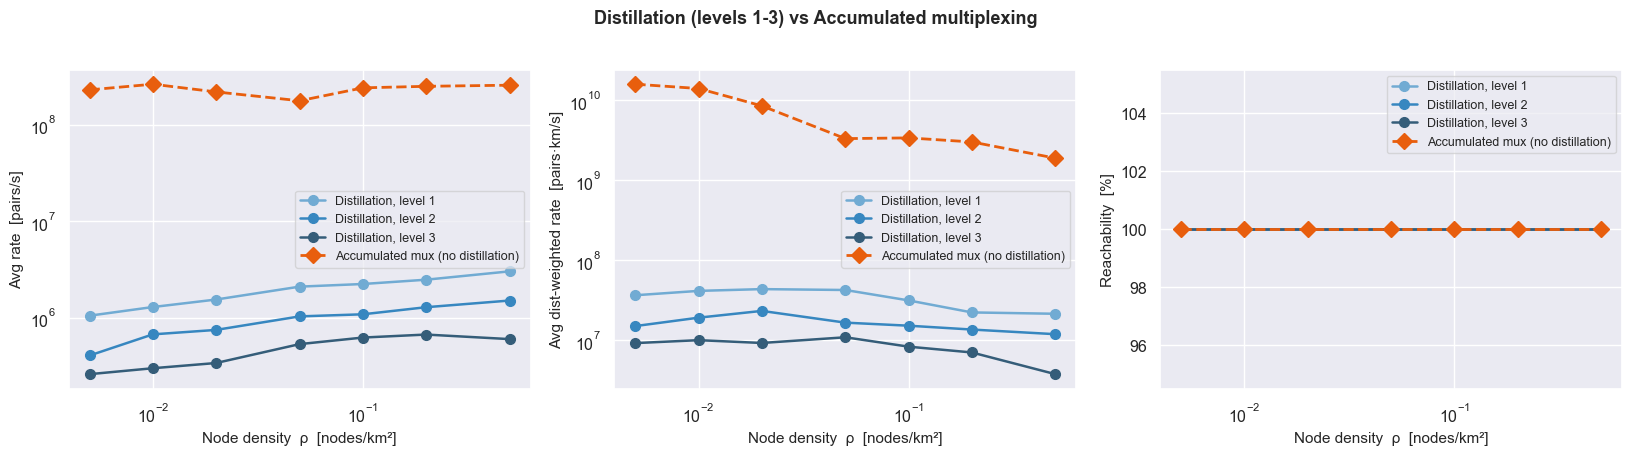

Figure 4 saved.


In [7]:
palette4_dist = sns.color_palette('Blues_d', len(DIST_LEVELS))
palette4_acc  = sns.color_palette('Oranges_d', 1)

fig4, axes4 = make_fig(title='Distillation (levels 1-3) vs Accumulated multiplexing')

# Distillation lines
for li, lv in enumerate(DIST_LEVELS):
    label    = f'Distillation, level {lv}'
    row_data = {m: [] for m in METRICS}

    for rho in RHOS:
        scale_km = density_to_scale(N_NODES, rho)
        print(f'  distillation | level={lv} | rho={rho} …')
        res = run_metrics(
            scale_km,
            distillation=True,
            multiplexing_type=None,
            distillation_level=lv,
            distillation_time='before_swap',
        )
        for m in METRICS:
            row_data[m].append(res[m])

    for ax, m in zip(axes4, METRICS):
        ax.plot(RHOS, row_data[m], marker='o', color=palette4_dist[li],
                label=label, linewidth=1.8, markersize=7)

# Accumulated multiplexing line (no distillation)
row_data_acc = {m: [] for m in METRICS}
for rho in RHOS:
    scale_km = density_to_scale(N_NODES, rho)
    print(f'  accumulated | rho={rho} …')
    res = run_metrics(
        scale_km,
        distillation=False,
        multiplexing_type='accumulated',
        distillation_level=1,
        distillation_time='before_swap',
    )
    for m in METRICS:
        row_data_acc[m].append(res[m])

for ax, m in zip(axes4, METRICS):
    ax.plot(RHOS, row_data_acc[m], marker='D', linestyle='--',
            color=palette4_acc[0], label='Accumulated mux (no distillation)',
            linewidth=2.0, markersize=8)

finish_axes(axes4, xlabel='Node density  ρ  [nodes/km²]')
for ax in axes4:
    ax.set_xscale('log')
plt.tight_layout()
plt.savefig('plots/fig4_dist_vs_accumulated.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## Figure 5 — Distillation vs Single-burst multiplexing
Lines:
- Distillation ON, mux=None, levels 1/2/3 (before swap)
- mux=single_burst, distillation ON, levels 1/2/3 (acts as parallel distillation)

X-axis = density.

  distillation | level=1 | rho=0.005 …
  distillation | level=1 | rho=0.01 …
  distillation | level=1 | rho=0.02 …
  distillation | level=1 | rho=0.05 …
  distillation | level=1 | rho=0.1 …
  distillation | level=1 | rho=0.2 …
  distillation | level=1 | rho=0.5 …
  distillation | level=2 | rho=0.005 …
  distillation | level=2 | rho=0.01 …
  distillation | level=2 | rho=0.02 …
  distillation | level=2 | rho=0.05 …
  distillation | level=2 | rho=0.1 …
  distillation | level=2 | rho=0.2 …
  distillation | level=2 | rho=0.5 …
  distillation | level=3 | rho=0.005 …
  distillation | level=3 | rho=0.01 …
  distillation | level=3 | rho=0.02 …
  distillation | level=3 | rho=0.05 …
  distillation | level=3 | rho=0.1 …
  distillation | level=3 | rho=0.2 …
  distillation | level=3 | rho=0.5 …
  single_burst | level=1 | rho=0.005 …
  single_burst | level=1 | rho=0.01 …
  single_burst | level=1 | rho=0.02 …
  single_burst | level=1 | rho=0.05 …
  single_burst | level=1 | rho=0.1 …
  single_burst | l

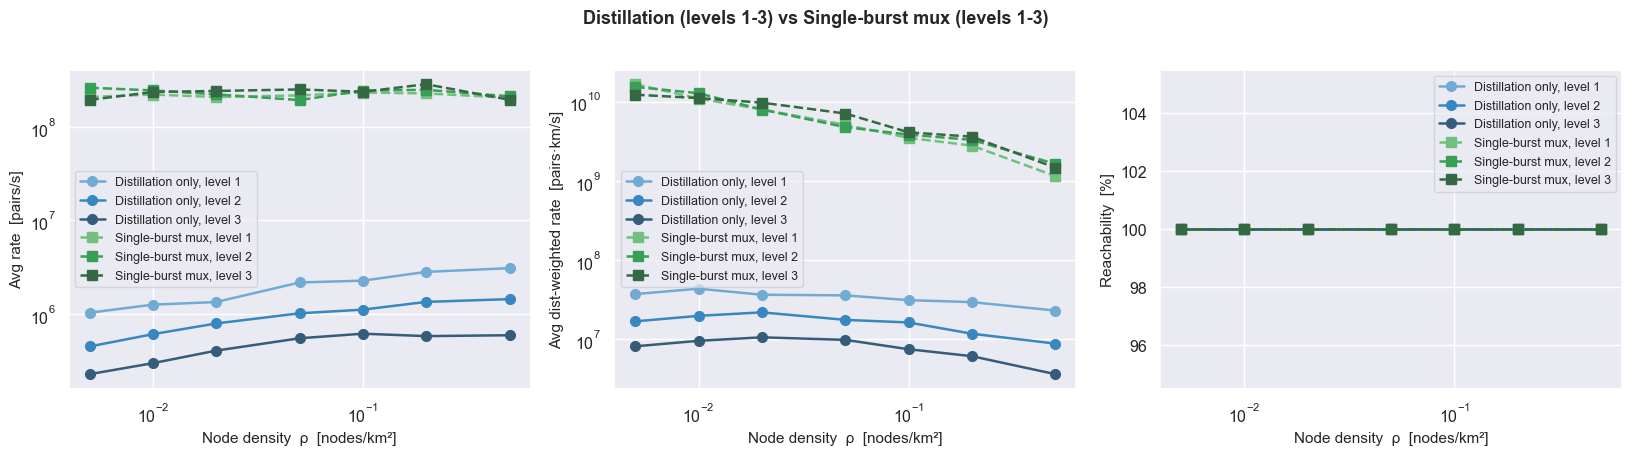

Figure 5 saved.


In [8]:
palette5_dist  = sns.color_palette('Blues_d',   len(DIST_LEVELS))
palette5_burst = sns.color_palette('Greens_d',  len(DIST_LEVELS))

fig5, axes5 = make_fig(title='Distillation (levels 1-3) vs Single-burst mux (levels 1-3)')

# Distillation-only lines (same as Fig 4)
for li, lv in enumerate(DIST_LEVELS):
    label    = f'Distillation only, level {lv}'
    row_data = {m: [] for m in METRICS}

    for rho in RHOS:
        scale_km = density_to_scale(N_NODES, rho)
        print(f'  distillation | level={lv} | rho={rho} …')
        res = run_metrics(
            scale_km,
            distillation=True,
            multiplexing_type=None,
            distillation_level=lv,
            distillation_time='before_swap',
        )
        for m in METRICS:
            row_data[m].append(res[m])

    for ax, m in zip(axes5, METRICS):
        ax.plot(RHOS, row_data[m], marker='o', color=palette5_dist[li],
                linestyle='-', label=label, linewidth=1.8, markersize=7)

# Single-burst + distillation lines
for li, lv in enumerate(DIST_LEVELS):
    label    = f'Single-burst mux, level {lv}'
    row_data = {m: [] for m in METRICS}

    for rho in RHOS:
        scale_km = density_to_scale(N_NODES, rho)
        print(f'  single_burst | level={lv} | rho={rho} …')
        res = run_metrics(
            scale_km,
            distillation=True,
            multiplexing_type='single_burst',
            distillation_level=lv,
            distillation_time='before_swap',
        )
        for m in METRICS:
            row_data[m].append(res[m])

    for ax, m in zip(axes5, METRICS):
        ax.plot(RHOS, row_data[m], marker='s', color=palette5_burst[li],
                linestyle='--', label=label, linewidth=1.8, markersize=7)

finish_axes(axes5, xlabel='Node density  ρ  [nodes/km²]')
for ax in axes5:
    ax.set_xscale('log')
plt.tight_layout()
plt.savefig('plots/fig5_dist_vs_singleburst.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')